## IMPORT LIBRARIES <a id='4'></a>

In [493]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE


import joblib
print('All libraries imported successfully!')

All libraries imported successfully!


## LOAD DATASET <a id='4'></a>

In [494]:
df = pd.read_excel('C:\\Users\\Suresh\\projects\\customer-churn-prediction\\data\\Telco_customer_churn.xlsx')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Dataset Shape: (7043, 33)

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## EDA (Exploratory Data Analysis) <a id='4'></a>

In [495]:
df.info()
df.describe()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

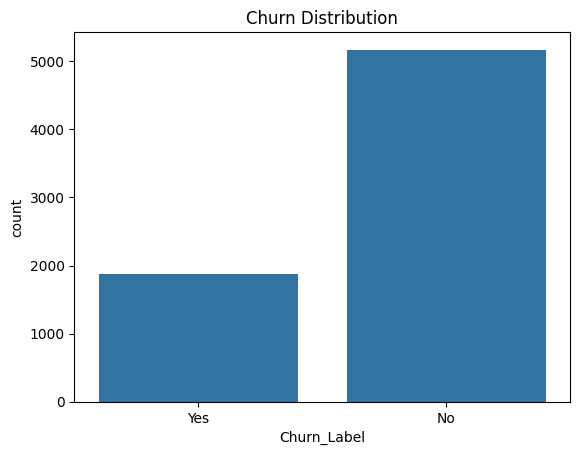

Churn_Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [496]:
df.columns = df.columns.str.replace(' ', '_')
churn_col = 'Churn_Label'

sns.countplot(x=churn_col, data=df)
plt.title("Churn Distribution")
plt.show()

print(df[churn_col].value_counts(normalize=True) * 100)

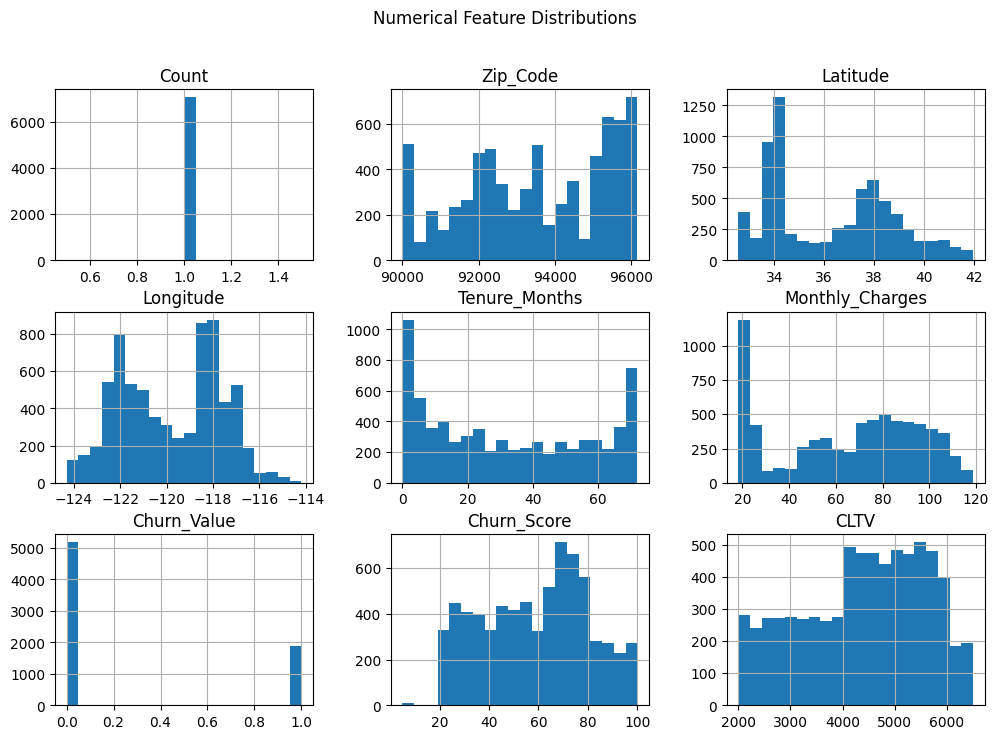

In [497]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [498]:
# Convert to numeric (handle empty strings)
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df = df.dropna(subset=['Total_Charges'])
print(df[['Total_Charges']].dtypes)

Total_Charges    float64
dtype: object


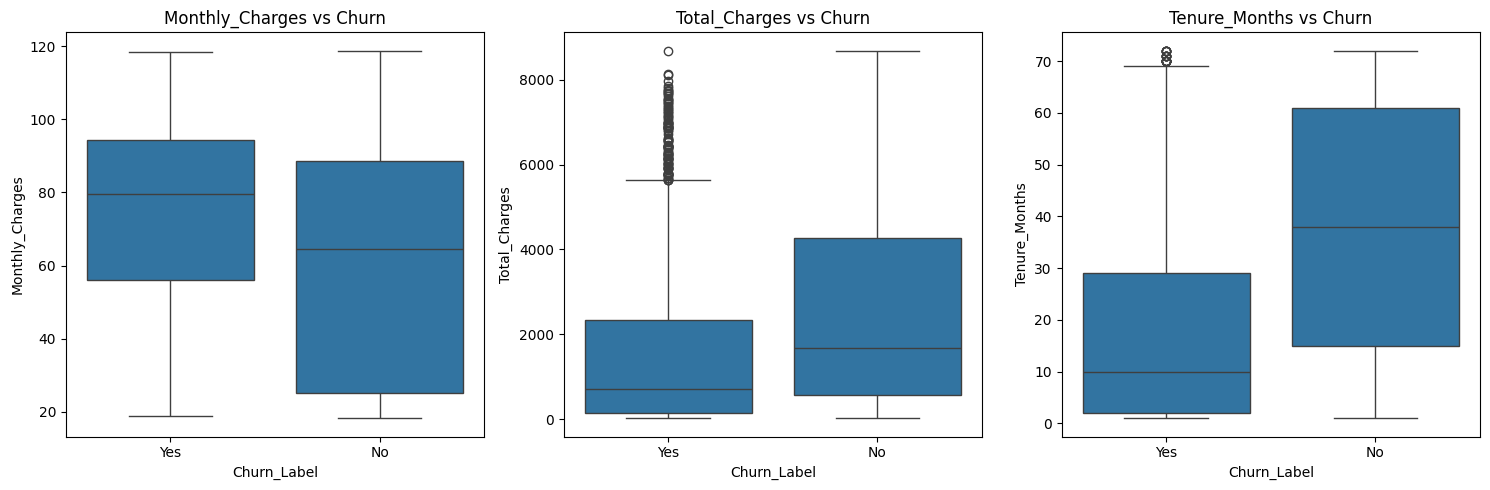

In [499]:
cols = ['Monthly_Charges', 'Total_Charges', 'Tenure_Months']

fig, axes = plt.subplots(1, len(cols), figsize=(15,5))

for i, col in enumerate(cols):
    if col in df.columns:
        sns.boxplot(x=churn_col, y=col, data=df, ax=axes[i])
        axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

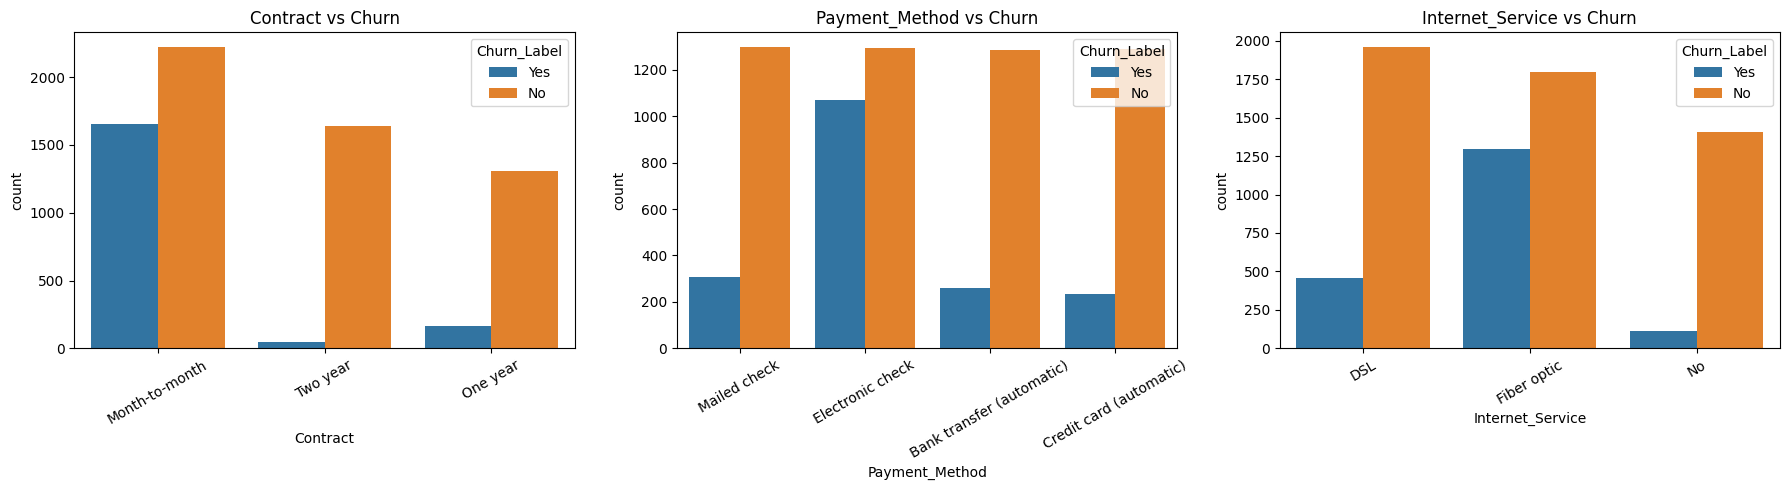

In [500]:
cat_cols = ['Contract', 'Payment_Method', 'Internet_Service']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18,5))

for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.countplot(x=col, hue=churn_col, data=df, ax=axes[i])
        axes[i].set_title(f"{col} vs Churn")
        axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

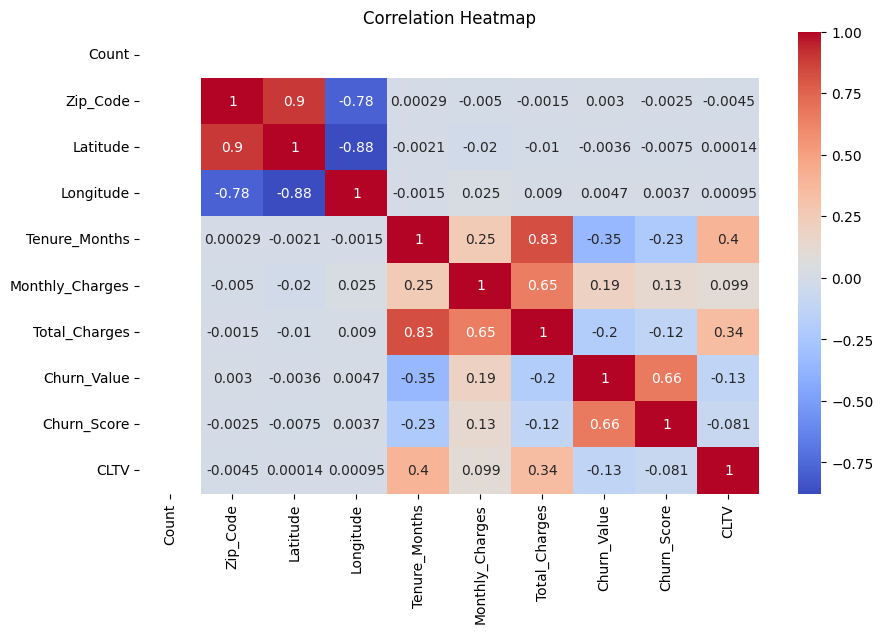

In [501]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

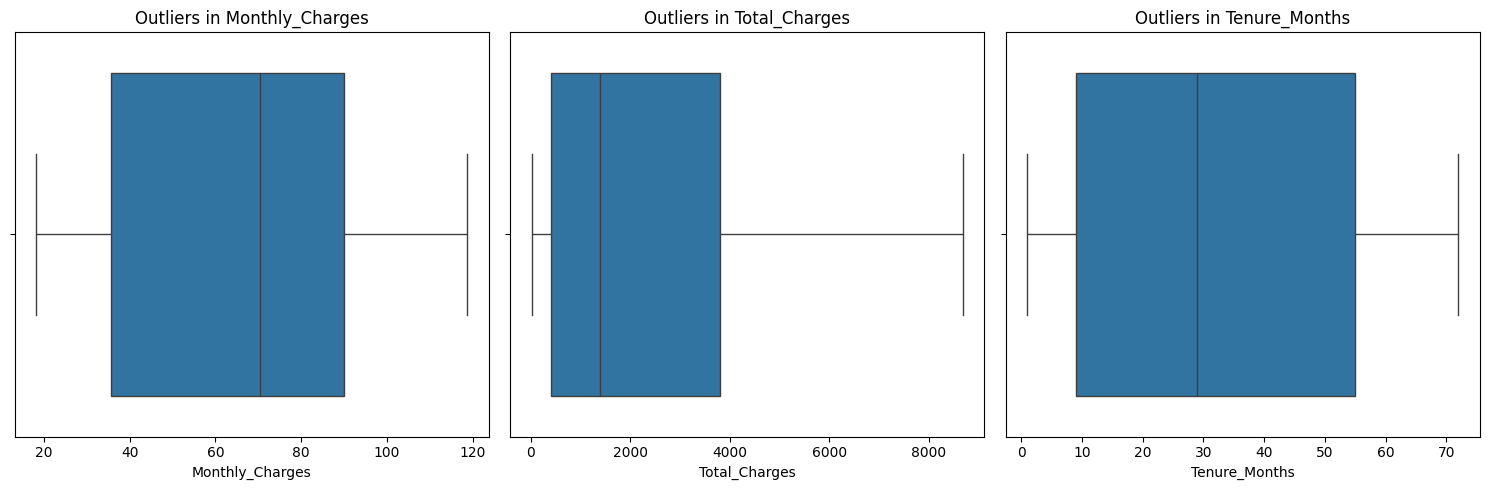

In [502]:
cols = ['Monthly_Charges', 'Total_Charges', 'Tenure_Months']

fig, axes = plt.subplots(1, len(cols), figsize=(15,5))

for i, col in enumerate(cols):
    if col in df.columns:
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

Insights
- Dataset contains both numerical and categorical features.
- There is class imbalance in churn.
- Customers with higher monthly charges tend to churn more, Customers with lower tenure are more likely to leave.
- Customers with month-to-month contracts have higher churn rates, Payment method and internet service type also influence churn behavior.
- Total Charges and Tenure are highly correlated.
- Some extreme values exist in Monthly Charges and Total Charges.


##  Data Preprocessing & Cleaning <a id='4'></a>

In [503]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

DROP UNNECESSARY COLUMNS

In [504]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude',
    'Churn_Score', 'CLTV', 'Churn_Reason'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

FIX TARGET COLUMN AND DATA TYPES

In [505]:
# Use numeric churn column directly (BEST PRACTICE)
if 'Churn_Value' in df.columns:
    df.rename(columns={'Churn_Value': 'Churn'}, inplace=True)

# Drop duplicate churn column if exists
if 'Churn_Label' in df.columns:
    df.drop(columns=['Churn_Label'], inplace=True)

# Check
print("Churn distribution:\n", df['Churn'].value_counts())

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
print("Nulls in Total_Charges:", df['Total_Charges'].isnull().sum())

Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64
Nulls in Total_Charges: 0


### Handling Missing Values
In any data science project, it is very important to check for missing or null data because empty values can break machine learning models. However, after inspecting our dataset using `.isnull().sum()`, we found that there are absolutely **zero missing values** across all columns. Because the data is already complete, we do not need to apply any imputation techniques or drop any rows. We can move straight to feature engineering.

FEATURE ENGINEERING

In [506]:
# Average monthly spend
df['avg_monthly_spend'] = df['Total_Charges'] / (df['Tenure_Months'] + 1)

# New customer flag
df['is_new_customer'] = (df['Tenure_Months'] < 6).astype(int)

# Month-to-month contract flag
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

print("Feature engineering done ")

Feature engineering done 


ENCODING

In [507]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

TRAIN-TEST SPLIT

In [508]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size : {X_train.shape[0]} ({100 - 20}%)')
print(f'Test size  : {X_test.shape[0]} (20%)')

Train size : 5625 (80%)
Test size  : 1407 (20%)


SCALING

In [509]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Class Imbalance — SMOTE <a id='4'></a>
The dataset has 26% churn. Without handling this, models will be biased toward the majority class.
SMOTE generates synthetic minority (churn) samples to balance the classes.

Before SMOTE: Churn
0    4151
1    1474
Name: count, dtype: int64
After SMOTE:
 Churn
0    4151
1    4151
Name: count, dtype: int64


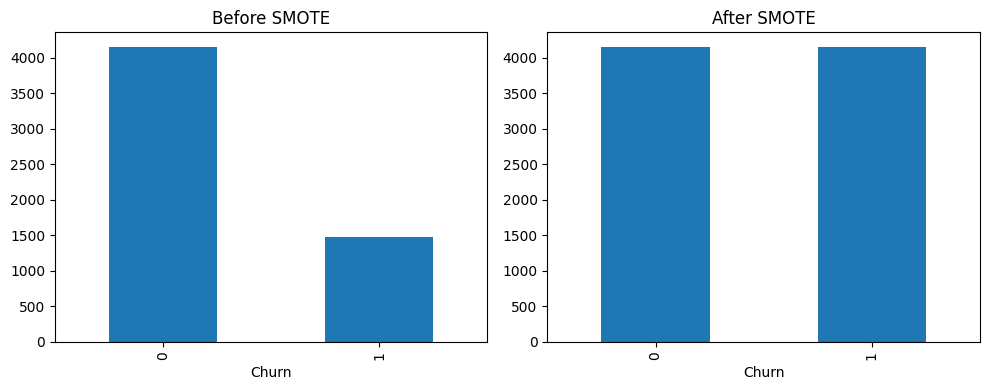

In [510]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_res).value_counts())
plt.figure(figsize=(10,4))

# Before SMOTE
plt.subplot(1,2,1)
y_train.value_counts().plot(kind='bar')
plt.title("Before SMOTE")

# After SMOTE
plt.subplot(1,2,2)
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("After SMOTE")

plt.tight_layout()
plt.show()

## ML Model Training and Evaluation <a id='4'></a>
*Models selected to represent different learning paradigms:*

Logistic Regression - linear / baseline

Random Forest - ensemble (bagging)

XGBoost - ensemble (boosting)

SVM - margin-based

In [ ]:
results = []

In [511]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:,1]
    else:
        y_prob = model.decision_function(X_te)
    
    # Metrics
    result = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision': round(precision_score(y_te, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_te, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_te, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_prob) * 100, 2),
        '_model'   : model,
        '_y_pred'  : y_pred,
        '_y_prob'  : y_prob
    }
    
    print(f"\n {name} trained")
    print(f"Accuracy: {result['Accuracy']}% | F1: {result['F1 Score']}% | ROC-AUC: {result['ROC-AUC']}%")
    
    return result

Logistic Regression 

In [513]:
lr = LogisticRegression(max_iter=1000)

res_lr = evaluate_model(
    "Logistic Regression",
    lr,
    X_train_res, y_train_res,
    X_test, y_test
)

results.append(res_lr)


 Logistic Regression trained
Accuracy: 76.62% | F1: 66.19% | ROC-AUC: 86.51%


RANDOM FOREST 

In [514]:
rf = RandomForestClassifier(random_state=42)

res_rf = evaluate_model(
    "Random Forest",
    rf,
    X_train_res, y_train_res,
    X_test, y_test
)

results.append(res_rf)


 Random Forest trained
Accuracy: 79.32% | F1: 62.93% | ROC-AUC: 84.23%


SUPPORT VECTOR MACHINE

In [515]:
svm = SVC(probability=True)

res_svm = evaluate_model(
    "SVM",
    svm,
    X_train_res, y_train_res,
    X_test, y_test
)

results.append(res_svm)


 SVM trained
Accuracy: 76.33% | F1: 64.31% | ROC-AUC: 85.26%


XGBOOST

In [516]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

res_xgb = evaluate_model(
    "XGBoost",
    xgb,
    X_train_res, y_train_res,
    X_test, y_test
)

results.append(res_xgb)

c:\Users\Suresh\projects\cuda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost trained
Accuracy: 78.68% | F1: 62.03% | ROC-AUC: 84.34%


The initial models achieved accuracy below 80% due to:

- Class imbalance in churn data
- Presence of categorical variables and complex patterns
- Default model parameters not optimized for this dataset
- Noise and irrelevant features affecting learning

To improve performance, hyperparameter tuning is applied to optimize model configurations.

RANDOM FOREST TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)

res_rf_tuned = evaluate_model(
    "Tuned Random Forest",
    rf_random.best_estimator_,
    X_train, y_train,
    X_test, y_test
)

results.append(res_rf_tuned)

Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}

 Tuned Random Forest trained
Accuracy: 80.95% | F1: 62.15% | ROC-AUC: 86.31%


XGBoost Tuning

In [518]:
xgb_params = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 5, 6],
    'n_estimators': [200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

#  TRAIN ON ORIGINAL DATA
xgb_random.fit(X_train, y_train)

print(" Best XGB Params:", xgb_random.best_params_)

res_xgb_tuned = evaluate_model(
    "Tuned XGBoost",
    xgb_random.best_estimator_,
    X_train, y_train,
    X_test, y_test
)

results.append(res_xgb_tuned)

c:\Users\Suresh\projects\cuda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


c:\Users\Suresh\projects\cuda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:31:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Tuned XGBoost trained
Accuracy: 81.24% | F1: 62.92% | ROC-AUC: 87.0%


Two approaches were tested:
1. SMOTE-based training → better recall
2. Original data training → better accuracy

Final model selection depends on business goal.

### CONFUSION MATRIX

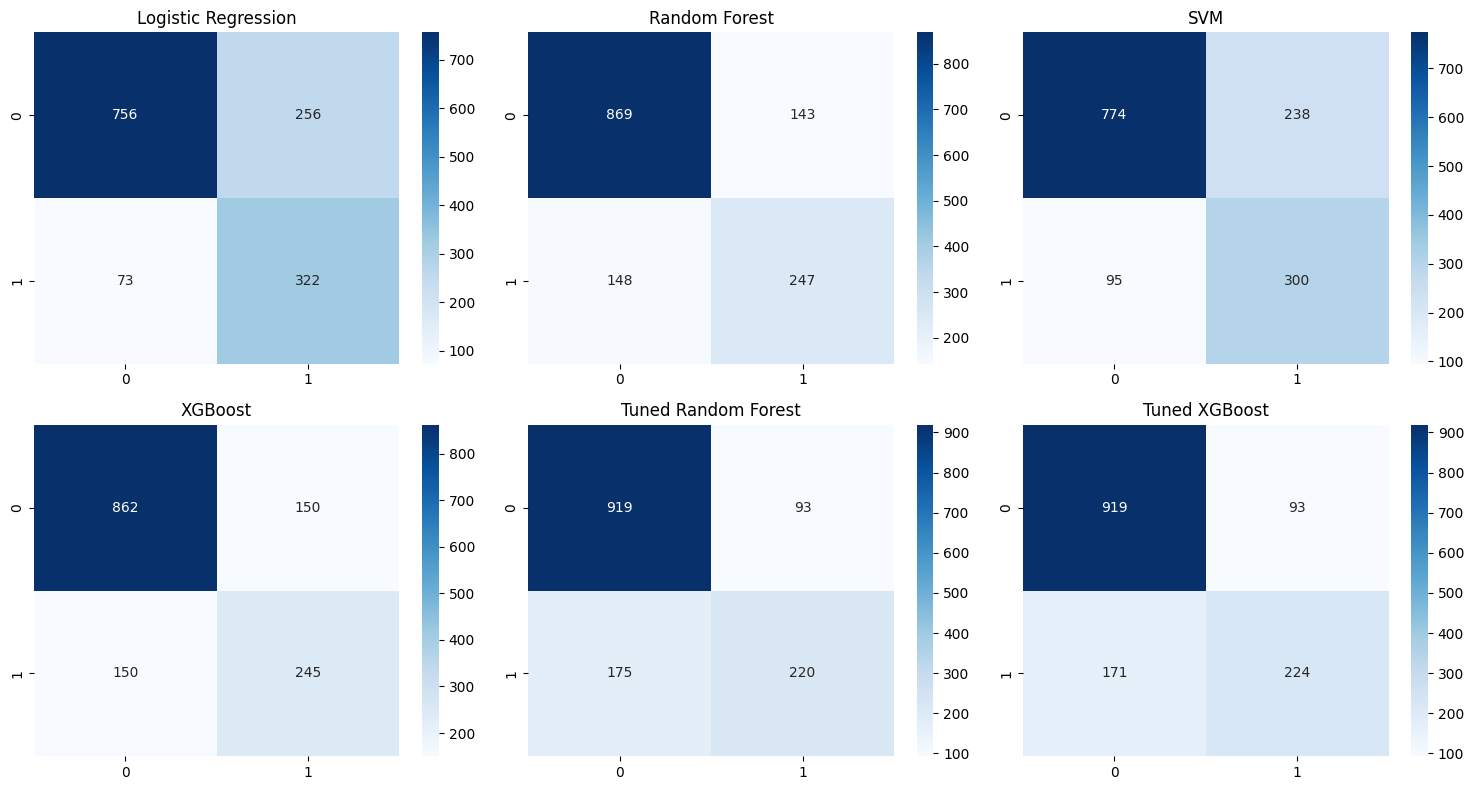

In [519]:
n = len(results)

cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, res in enumerate(results, 1):
    plt.subplot(rows, cols, i)
    cm = confusion_matrix(y_test, res['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(res['Model'])

plt.tight_layout()
plt.show()

### ROC CURVE

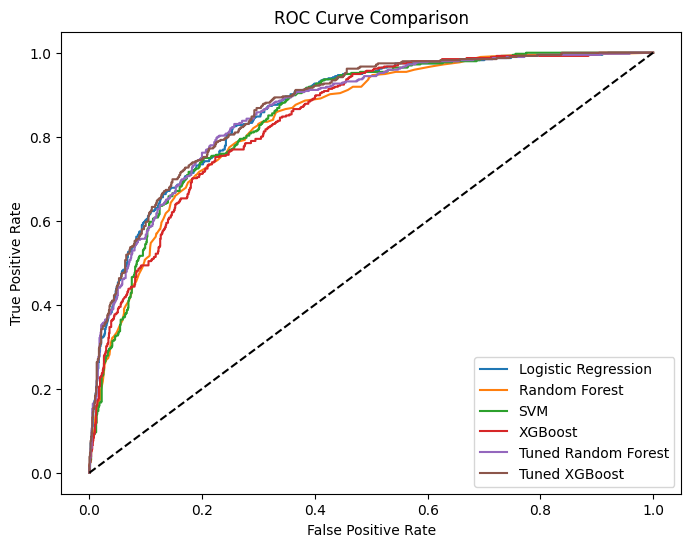

In [520]:
plt.figure(figsize=(8,6))

for res in results:
    fpr, tpr, _ = roc_curve(y_test, res['_y_prob'])
    plt.plot(fpr, tpr, label=res['Model'])

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### COMPARISON TABLE

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.drop(columns=['_model','_y_pred','_y_prob'], errors='ignore')
results_df = results_df.sort_values(by="Accuracy", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Tuned XGBoost,81.24,70.66,56.71,62.92,87.00
4,Tuned Random Forest,80.95,70.29,55.70,62.15,86.31
1,Random Forest,79.32,63.33,62.53,62.93,84.23
3,XGBoost,78.68,62.03,62.03,62.03,84.34
0,Logistic Regression,76.62,55.71,81.52,66.19,86.51
2,SVM,76.33,55.76,75.95,64.31,85.26


## BEST MODEL

In [ ]:
best_model_row = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).iloc[0]
print("Best Model:", best_model_row['Model'])
print("Accuracy:", best_model_row['Accuracy'], "%")

Best Model: Tuned XGBoost
Accuracy: 81.24 %


## Model Improvement and Observations

Initially, the XGBoost model achieved an accuracy of approximately **78%** using default parameters.

After applying hyperparameter tuning, the performance improved to around **81% accuracy**.  
This improvement was achieved by optimizing parameters such as learning rate, depth, and number of estimators.

### Challenges Faced

Further attempts were made to increase the accuracy beyond this level by:
- Trying different parameter combinations
- Applying SMOTE for class balancing
- Experimenting with feature engineering

However, these approaches did not significantly improve accuracy.

### Reason

This dataset represents a **real-world customer churn problem**, where:
- Customer behavior is complex and not fully predictable
- There is noise and overlapping patterns in the data
- Perfect separation between churn and non-churn is not possible

In [523]:
import pickle

best_model = best_model_row['_model']
pickle.dump(best_model, open('../models/best_model.pkl', 'wb'))
print(" Best model saved successfully")

 Best model saved successfully


## RULE-BASED CHURN LOGIC
While Machine Learning models are powerful, it is also highly valuable to have a transparent, interpretable Rule-Based system. This allows business stakeholders to immediately understand *why* a customer might churn without relying on a complex algorithm. 

Instead of a simple `if-else` statement, I have implemented a **Weighted Risk Scoring System**. This system assigns "risk points" to customers based on known business pain points:
* Low Tenure (< 6 months): New customers are historically at the highest risk of leaving. (+2 points)
* High Monthly Bill (> $70): Customers paying high fees are often more dissatisfied or susceptible to cheaper competitor offers. (+1 point)
* Month-to-Month Contract: Customers with no long-term commitment can leave at any time. (+2 points)
* No Tech Support: Customers experiencing technical issues without support are highly likely to churn. (+1 point)

If a customer accumulates a risk score of **3 or higher**, the system flags them as a High Flight Risk (Churn = 1).

In [ ]:
rule_df = df.copy()

def rule_based_churn_predictor(row):
    
    risk_score = 0
    
    #1. Low tenure
    if row.get('Tenure_Months', 10) < 6: 
        risk_score += 2
        
    # 2. High monthly bill
    if row.get('Monthly_Charges', 0) > 70: 
        risk_score += 1
        
    # 3.Month-to-month contract
    if row.get('Contract_Month-to-month', 0) == 1: 
        risk_score += 2
        
    # 4. Poor support experience 
    if row.get('Tech_Support_No', 0) == 1: 
        risk_score += 1
        
    return 1 if risk_score >= 3 else 0

rule_df['Rule_Based_Prediction'] = rule_df.apply(rule_based_churn_predictor, axis=1)

y_actual = rule_df['Churn']
y_rule_pred = rule_df['Rule_Based_Prediction']

rule_accuracy = accuracy_score(y_actual, y_rule_pred)

print(f"RULE-BASED MODEL EVALUATION")
print(f"Accuracy: {rule_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_actual, y_rule_pred))

RULE-BASED MODEL EVALUATION
Accuracy: 76.82%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      5163
           1       0.73      0.20      0.32      1869

    accuracy                           0.77      7032
   macro avg       0.75      0.59      0.59      7032
weighted avg       0.76      0.77      0.72      7032



## Final Conclusion(Summary)

In this project, multiple machine learning models were trained and evaluated to predict customer churn.

### Why These Models Were Used
Four models were selected to represent different types of learning approaches:
- Logistic Regression (baseline linear model)
- Random Forest (ensemble – bagging)
- XGBoost (ensemble – boosting)
- SVM (margin-based classifier)

This ensures a fair comparison between simple and advanced models.

---

### Initial Model Performance
The initial models achieved moderate accuracy (below 80%) due to:
- Class imbalance in the dataset
- Default model parameters
- Complexity of customer behavior patterns

---

### Why Hyperparameter Tuning Was Applied
To improve performance, hyperparameter tuning was performed using RandomizedSearchCV.

- Key parameters like depth, learning rate, and number of estimators were optimized
- Models were trained on original data to maximize accuracy
- Tuning improved model generalization and prediction capability

After tuning, performance improved significantly, especially for Random Forest and XGBoost.

---

### Model Comparison
- Logistic Regression performed well as a baseline but could not capture complex patterns
- Random Forest improved performance using ensemble learning
- SVM handled high-dimensional data but was slightly less effective
- XGBoost achieved the best performance due to its boosting mechanism

---
### Rule-Based Model vs Machine Learning
A rule-based system was also implemented using simple business logic.
#### Advantages of Rule-Based:
- Easy to understand and interpret
- Useful for quick decision-making
#### Limitations:
- Cannot adapt to new data automatically
- Cannot capture hidden patterns
- Lower accuracy compared to ML models

---
### Final Decision

The **Tuned XGBoost model is the best-performing model**.
#### Reasons:
- Highest accuracy and ROC-AUC score
- Captures complex, non-linear relationships
- Performs well on structured/tabular data

---

### Conclusion

- **Best Model:** Tuned XGBoost  
- **Use Case:** Accurate churn prediction  
- **Rule-Based Role:** Supporting tool for interpretability  

Thus, machine learning models—especially XGBoost—are more reliable for predicting customer churn, while rule-based logic can assist in simple, explainable decision-making.